# MSE StatDig : Chap 7 "Optimum filter"
## Ex 7.1 FIR Wiener Filter
ver : DLY/10.04.2026

## General

### Description

In the filtering problem, a signal d[n], whose autocorrelation is known, is to be estimated from a noise corrupted observation : $x[n] = d[n] + v[n]$

![filter](src/FIR-Wiener-71.png)


Let d[n] be an AR(1) process excited by a zero mean white noise with unit variance:

$d[n] = a[1]d[n-1] + w[n]$

and suppose that d[n] is observed in the presence of uncorrelated white noise v[n] with variance $\sigma_v^2$. The signal d[n] has a unit variance.

The goal is to filter x[n] with Wiener filter W(z) to estimate d[n].

### Work

#### Ex1 : Signal generation

- Display the signals created by the following code :

```python
a1 = 0.8
SigmaW = 1
SigmaV = 1
N = 500
p = 2
worder = p-1

# fix the random seed for reproducibility
np.random.seed(0)

wn = SigmaW*np.random.normal(0,1,N) # noise process
vn = SigmaV*np.random.normal(0,1,N) # measurement noise
d = signal.lfilter(1,np.array([1,-a1]),wn) #AR(1) process

d = d / np.sqrt (np.sum(d**2)/N) # division by the std to have a unit variance
x = d+vn; # noisy measured signal
```

In [340]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt

In [341]:
a1 = 0.8
SigmaW = 1
SigmaV = 1
N = 500
p = 2
worder = p-1

# fix the random seed for reproducibility
np.random.seed(0)

wn = SigmaW*np.random.normal(0,1,N) # noise process
vn = SigmaV*np.random.normal(0,1,N) # measurement noise
d = signal.lfilter(1,np.array([1,-a1]),wn) #AR(1) process

d = d / np.sqrt (np.sum(d**2)/N) # division by the std to have a unit variance
x = d+vn; # noisy measured signal

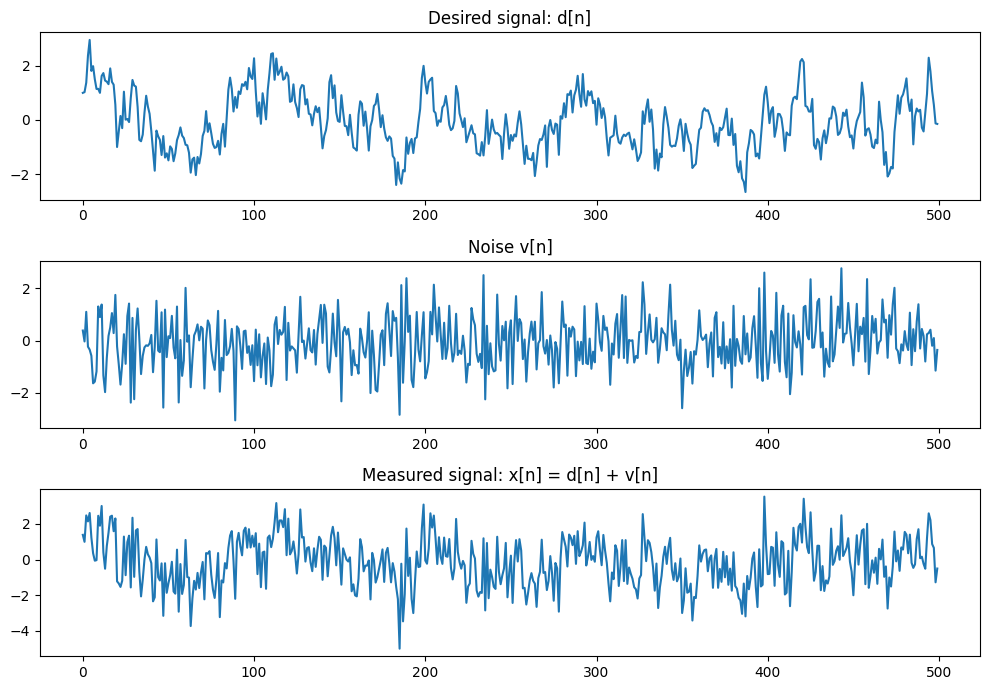

In [342]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(3, 1, 1)      # initialize the top Axes
ax1.plot(d)                      # plot the top graph
plt.title('Desired signal: d[n]')
fig.tight_layout()

ax2 = fig.add_subplot(3, 1, 2)      # initialize the bottom left Axes
ax2.plot(vn)  # plot the bottom left graph
plt.title('Noise v[n]')
fig.tight_layout()

ax3 = fig.add_subplot(3, 1, 3)      # initialize the bottom right Axes
ax3.plot(x)
plt.title('Measured signal: x[n] = d[n] + v[n]')
fig.tight_layout()

#### Ex2 : Theoretical Wiener filter
##### Ex2.1 Design filter

By knowing the signal characteristics, the Wiener filter based on its theoretical statistical parameters can be designed:
By assuming that `v[n]` is zero-mean and not correlated with `d[n]`, the Wiener-Hopf equation is simplified to :

$$\left[R_d + R_v \right]w=r_d$$

As the process `d[n]` is a AR(1) the theoretical auto-correlation of the desired signal is known.  For a first order Wiener filter (p=2), the theoretical autocorrelation matrix can be built:

$$r_d[k] = \alpha^{k} \; with \; \alpha = a=0.8$$

$$
\mathbf{R}_d = 
\begin{bmatrix}
r_d[0] & r_d[1] \\
r_d[1] & r_d[0]
\end{bmatrix}
=
\begin{bmatrix}
1 & \alpha \\
\alpha & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0.8 \\
0.8 & 1
\end{bmatrix}
$$

$$
\mathbf{r}_d = 
\begin{bmatrix}
r_d[0] \\
r_d[1]
\end{bmatrix}
=
\begin{bmatrix}
1 \\
\alpha
\end{bmatrix}
=
\begin{bmatrix}
1 \\
0.8
\end{bmatrix}
$$
         
 
As the noise has a unit variance, the theoretical autocorrelation of the noise is known:

$$
r_v[k] = \sigma_v^2 \delta[k] = \delta[k]
$$

$$
\mathbf{R}_v =
\begin{bmatrix}
\sigma_v^2 & 0 \\
0 & \sigma_v^2
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$


It gives the theoretical Wiener-Hopf equation

$$
\left[
\begin{array}{cc}
1 & \alpha \\
\alpha & 1
\end{array}
\right]
+
\left[
\begin{array}{cc}
\sigma_v^2 & 0 \\
0 & \sigma_v^2
\end{array}
\right]
\left[
\begin{array}{c}
w[0] \\
w[1]
\end{array}
\right]
=
\begin{bmatrix}
1 \\
\alpha
\end{bmatrix}
$$

$$
\left[
\begin{array}{cc}
2 & 0.8 \\
0.8 & 2
\end{array}
\right]
\left[
\begin{array}{c}
w[0] \\
w[1]
\end{array}
\right]
=
\begin{bmatrix}
1 \\
0.8
\end{bmatrix}
$$



By solving that Wiener-Hopf equation, the Wiener coefficient can be estimated:

$$
\begin{bmatrix}
w[0] \\
w[1]
\end{bmatrix}
=
\begin{bmatrix}
2 & 0.8 \\
0.8 & 2
\end{bmatrix}^{-1}
\begin{bmatrix}
1 \\
0.8
\end{bmatrix}
=
\begin{bmatrix}
0.4048 \\
0.2381
\end{bmatrix}
$$


The theoretical squared norm minimum error can be determined:

$$
\xi_{\text{min}} = r_d[0] - w[0] r_d[0] - w[1] r_d[1] = 0.4048
$$


- Implement the function `wienerFilterTheo()` and test it. It should give the above theoretical results :

```python
def wienerFilterTheo(sigmaV,a,order):
# computes the weights of the Wiener FIR based on the theoretical correlations
# Input : 
# - sigmaV : (scalar) standrad deviation of the noise
# - a      : (scalar) coefficient of the AR(1)
# - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
# Output : 
# - w    : (p,) weights of the FIR wiener filter
# - E    : (scalar) theoretical squared norm minimum error
# - rd   : (p,) autocorrelation vector of the desired signal
# - Rd   : (p,p) autocorrelation matrix of the desired signal
# - Rv   : (p,p) autocorrelation matrix of the noise disturbance (v[n])
# - Rx   : (p,p) autocorrelation matrix of the input signal (x[n])

# your code here
#--

return w,E,rd,Rd,Rv,Rx
```

In [343]:
def wienerFilterTheo(sigmaV,a,order):
    # computes the weights of the Wiener FIR based on the theoretical correlations
    # Input : 
    # - sigmaV : (scalar) standrad deviation of the noise
    # - a      : (scalar) coefficient of the AR(1)
    # - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # Output : 
    # - w    : (p,) weights of the FIR wiener filter
    # - E    : (scalar) theoretical squared norm minimum error
    # - rd   : (p,) autocorrelation vector of the desired signal
    # - Rd   : (p,p) autocorrelation matrix of the desired signal
    # - Rv   : (p,p) autocorrelation matrix of the noise disturbance (v[n])
    # - Rx   : (p,p) autocorrelation matrix of the input signal (x[n])
    p = order + 1

    rd = a ** np.arange(p)
    Rd = toeplitz(rd)
    Rv = sigmaV**2 * np.eye(p)
    Rx = Rd + Rv
    w = np.linalg.solve(Rx, rd)
    E = rd[0] - w @ rd

    return w,E,rd,Rd,Rv,Rx

##### Ex2.2 Display the autocorrelation vectors

- Display Rd, rd and Rx for lags between -20 to 10

In [344]:
lags = np.arange(-20, 11)
rd_k = 0.8 ** abs(lags)
rv_k = (lags == 0)
rx_k = rd_k + rv_k

Text(0.5, -14.277777777777676, 'lags')

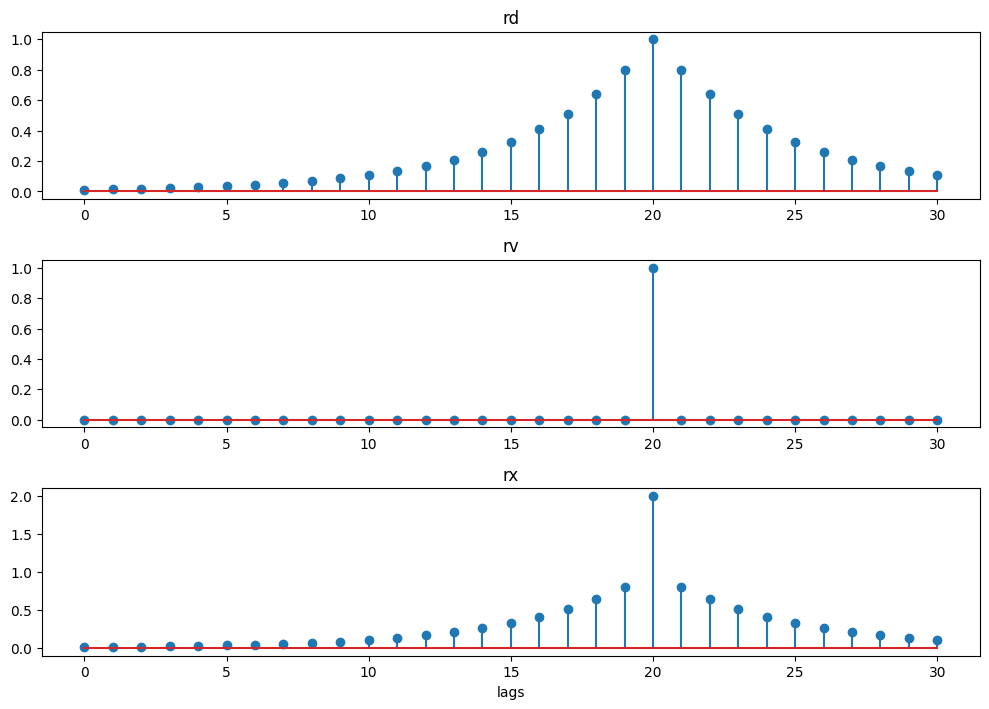

In [345]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(3, 1, 1)      # initialize the top Axes
ax1.stem(rd_k)                      # plot the top graph
plt.title('rd')
fig.tight_layout()

ax2 = fig.add_subplot(3, 1, 2)      # initialize the bottom left Axes
ax2.stem(rv_k)  # plot the bottom left graph
plt.title('rv')
fig.tight_layout()

ax3 = fig.add_subplot(3, 1, 3)      # initialize the bottom right Axes
ax3.stem(rx_k)
plt.title('rx')
fig.tight_layout()
plt.xlabel('lags')

##### Ex2.3 Frequency response of the filter
- Display the frequency response of the filter


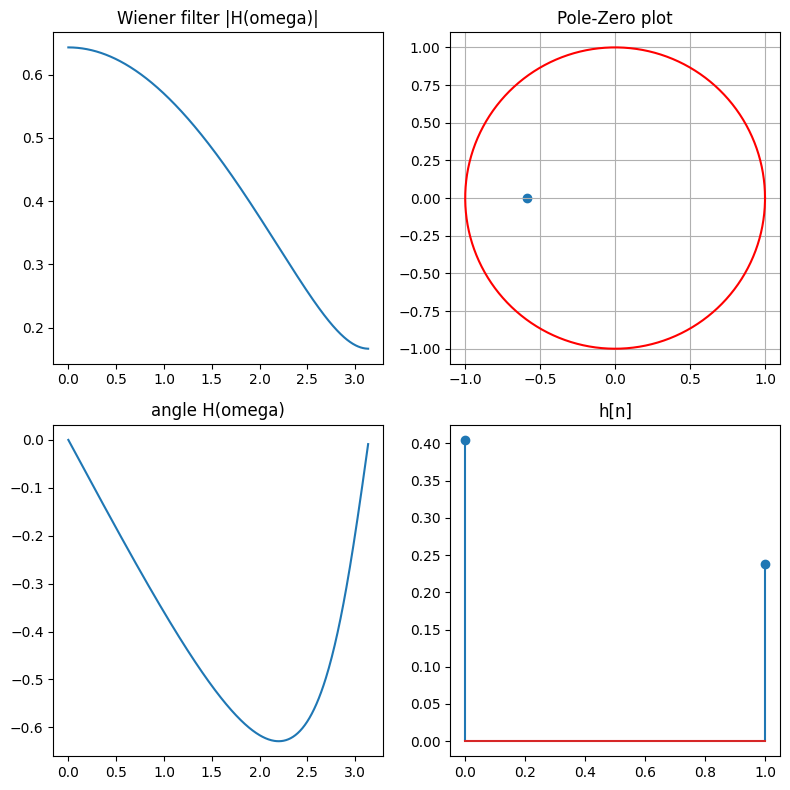

In [346]:
w, E, rd, Rd, Rv, Rx = wienerFilterTheo(SigmaV, a1, worder)
frequencies, H = freqz(w, worN=512)
H_abs = np.abs(H)
H_angle = np.angle(H)
zeros, poles, k = tf2zpk(w, [1])


fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(frequencies, H_abs)
ax1.set_title('Wiener filter |H(omega)|')

ax2 = fig.add_subplot(2, 2, 2)
theta = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta), np.sin(theta), 'r-')
ax2.scatter(zeros.real, zeros.imag, marker='o')
ax2.scatter(poles.real, poles.imag, marker='x')
ax2.set_title('Pole-Zero plot')
plt.grid()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(frequencies, H_angle)
ax3.set_title('angle H(omega)')

ax4 = fig.add_subplot(2, 2, 4)
ax4.stem(np.arange(len(w)), w)
ax4.set_title('h[n]')

fig.tight_layout()
plt.show()

##### Ex2.4 : Filter the signal

- Filter the signal x[n] with the Wiener filter and display the result.
- Display the filtered signal dhat and the original signal in the same figure.
- Display the mean square error where e[n] = d[n] - dhat[n] 

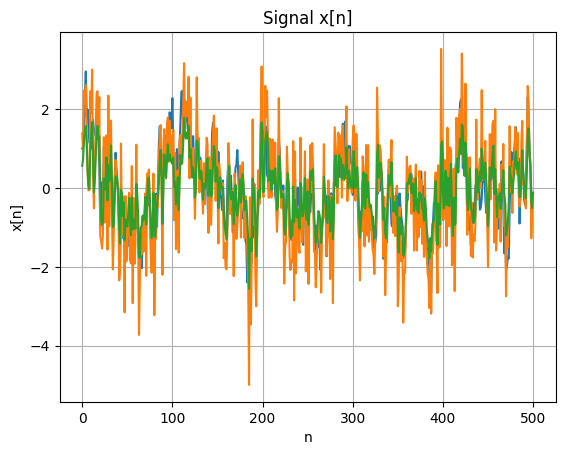

In [347]:
dhat = np.convolve(w, x)

plt.figure()
plt.plot(d)
plt.plot(x)
plt.plot(dhat)
plt.title('Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

##### Ex 2.5 : Signal noise ratio
The SNR can be then determined before and after filtering.

**Prior to filtering**, since $r_d[0]=\sigma_d^2 = 1$  and $r_v[0]=\sigma_d^2 = 1$, then the power in `d[n]` is equal to the power in `v[n]`, $E\left( |d[n]|^2 \right) = E\left( |v[n]|^2 \right) = 1$, and the signal to noise ratio is:
$$
\text{SNR} = 10 \log_{10} \left( \frac{E\left[ |d[n]|^2 \right]}{E\left[ |v[n]|^2 \right]} \right) = 0~\text{dB}
$$


**After filtering**, the power in the signal can be estimated as follow (where w is the vector of the filter coefficients):
$$
E\left[ |d'[n]|^2 \right] = \mathbf{w}^T \mathbf{R}_d \mathbf{w}
$$

$$
E\left[ |v'[n]|^2 \right] = \mathbf{w}^T \mathbf{R}_v \mathbf{w}
$$

$$
\text{SNR} = 10 \log_{10} \left( 
\frac{E\left[ |d'[n]|^2 \right]}{E\left[ |v'[n]|^2 \right]} 
\right) = 2.3~\text{dB}
$$

Then the Wiener filter increases the SNR by more than 2dB.

In [348]:
Ed = w @ Rd @ w
Ev = w @ Rv @ w
SNR = 10 * np.log10(Ed / Ev)
SNR_before = 10 * np.log10(rd[0] / SigmaV**2)
print(SNR)
print(SNR_before)

2.3025185815993248
0.0


#### Ex 3: Estimated Wiener filter
##### Ex3.1 Estimated autocorrelation
The previous part was using the theoretical autocorrelation of the desired signal and of the noise. In practice, most of the time this has to be estimated from the signal.

- compute and display ($lags \in [-20,20] $) the autocorrelation of the estimated $r_d$ and compare it to the theoretical one

In [349]:
rd_est = np.correlate(d, d, mode='full') / len(d)
lags = np.arange(-20, 21)

rd_k = 0.8 ** abs(lags)
center = len(d) - 1
rd_est = rd_est[center-20 : center+21]

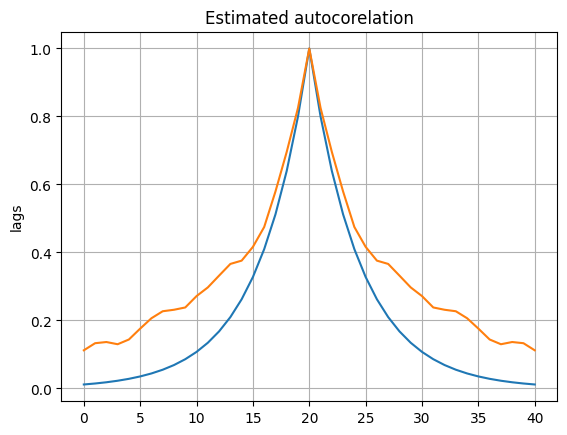

In [ ]:
plt.figure()
plt.plot(rd_k)
plt.plot(rd_est)
plt.title('Estimated autocorelation')
plt.ylabel('lags')
plt.grid()
plt.show()

##### Ex3.2 Wiener filter design
By using the estimated autocorrelation, the wiener filter can be designed using the same calculation than before.
On low order filter, the estimation and the theoretical gives very similar result. This is because the estimated autocorrelation is very close to the theoretical. The difference will increase with high filter order (p>1).

- Implement the function `wiener_fir()` and display the estimated filter coefficients

```python
def wiener_fir(x,d,order):
# computes the weights of the Wiener FIR based on the estimated correlations
# Input :
# - x     : (N,) input signal (noisy signal)
# - d     : (N,) desired signal (original signal)
# - order : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
# Output :
# - w    : (p,) weights of the FIR wiener filter
# - E    : (scalar) theoretical squared norm minimum error

# your code here
#--

return w,E
```

In [351]:
def wiener_fir(x,d,order):
    # computes the weights of the Wiener FIR based on the estimated correlations
    # Input :
    # - x     : (N,) input signal (noisy signal)
    # - d     : (N,) desired signal (original signal)
    # - order : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # Output :
    # - w    : (p,) weights of the FIR wiener filter
    # - E    : (scalar) theoretical squared norm minimum error

    p = order + 1
    N = len(x)

    # autocorrelation
    rxx = np.correlate(x, x, mode='full') / N
    mid = len(rxx) // 2
    rxx = rxx[mid:mid+p]

    Rx = toeplitz(rxx)

    # cross-correlation
    rdx = np.correlate(d, x, mode='full') / N
    rdx = rdx[mid:mid+p]

    # solve Wiener equation
    w = np.linalg.solve(Rx, rdx)

    # error
    E = np.mean(d**2) - np.dot(w, rdx)

    return w, E

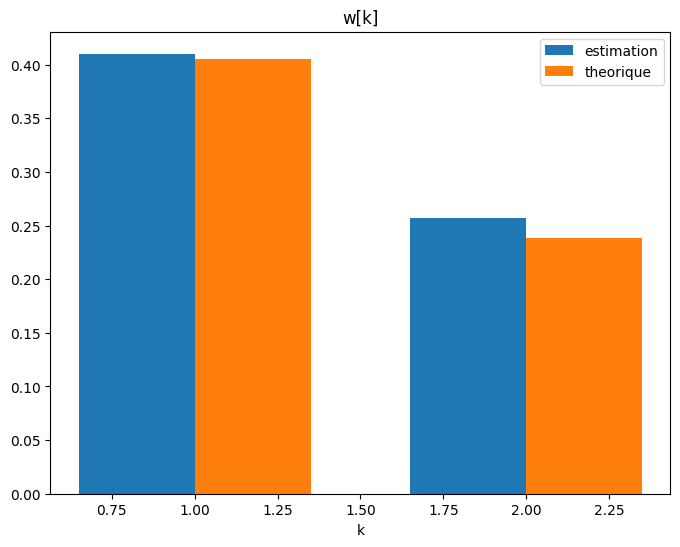

Erreur théorique : 0.4048
Erreur estimée   : 0.3973


In [352]:
# 1. Calcul des poids estimés
w_est, E_est = wiener_fir(x, d, worder)

# 2. Calcul des poids théoriques (déjà fait plus haut, mais on s'assure d'avoir w)
w_theo, E_theo, _, _, _, _ = wienerFilterTheo(SigmaV, a1, worder)

# 3. Préparation des indices pour l'axe x (k = 1, 2, ...)
k = np.arange(1, len(w_est) + 1)
width = 0.35  # Largeur des barres

# 4. Création du graphique
plt.figure(figsize=(8, 6))

# Barres pour l'estimation (décalées à gauche)
plt.bar(k - width/2, w_est, width, label='estimation')

# Barres pour la théorie (décalées à droite)
plt.bar(k + width/2, w_theo, width, label='theorique')

plt.title('w[k]')
plt.xlabel('k')
plt.xticks(np.arange(0.75, 2.5, 0.25))
plt.legend()
plt.show()

print(f"Erreur théorique : {E_theo:.4f}")
print(f"Erreur estimée   : {E_est:.4f}")

##### Ex3.3 Filter analysis and filtering
- Display again the frequency response as well the pole and zero and compare it to the theoretical results
- Filter the signal and display the mean square error (MSE) of : $e[n] = d[n]-dhat[n]$

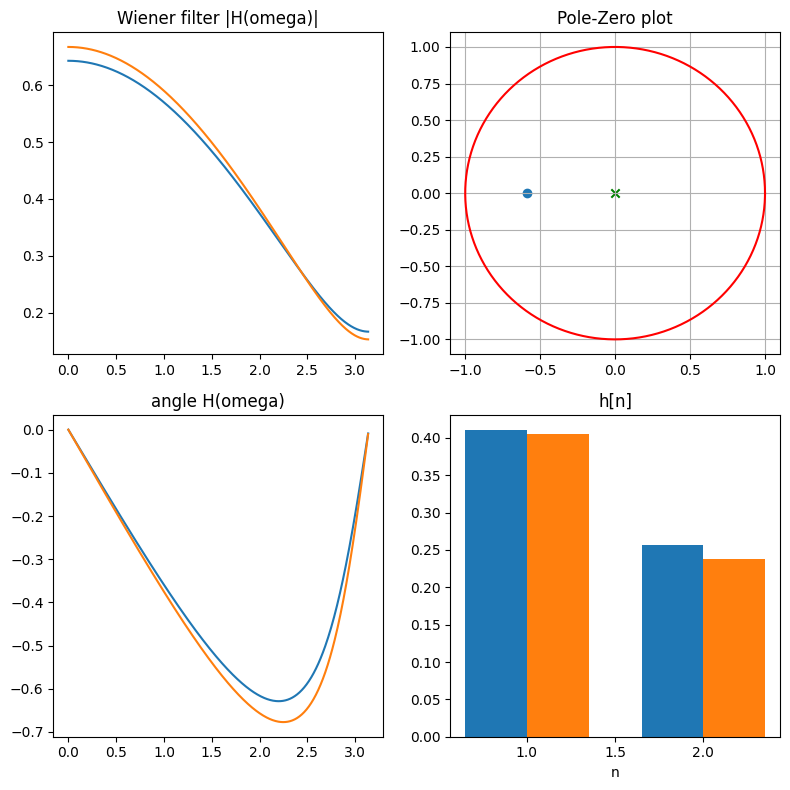

In [353]:
#Théorique :
frequencies, H_theo = freqz(w_theo, worN=512)
H_abs_theo = np.abs(H_theo)
H_angle_theo = np.angle(H_theo)
zeros_theo, poles_theo, k = tf2zpk(w_theo, [1])

#Estimé :
frequencies, H_est = freqz(w_est, worN=512)
H_abs_est = np.abs(H_est)
H_angle_est = np.angle(H_est)
zeros_est, poles_est, k = tf2zpk(w_est, [1])

#Paramètre hist.
width = 0.35
k = np.arange(1, len(w_est) + 1)


#graphiques
fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(frequencies, H_abs_theo)
ax1.plot(frequencies, H_abs_est)
ax1.set_title('Wiener filter |H(omega)|')

ax2 = fig.add_subplot(2, 2, 2)
theta = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta), np.sin(theta), 'r-')
ax2.scatter(0, 0, c='g',marker='x')
ax2.scatter(zeros.real, zeros.imag, marker='o')
ax2.scatter(poles.real, poles.imag, marker='x')
ax2.set_title('Pole-Zero plot')
plt.grid()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(frequencies, H_angle_theo)
ax3.plot(frequencies, H_angle_est)
ax3.set_title('angle H(omega)')

ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(k - width/2, w_est, width, label='estimation')
ax4.bar(k + width/2, w_theo, width, label='theorique')
ax4.set_title('h[n]')
ax4.set_xlabel('n')
ax4.set_xticks([1.0, 1.5, 2.0])

fig.tight_layout()
plt.show()

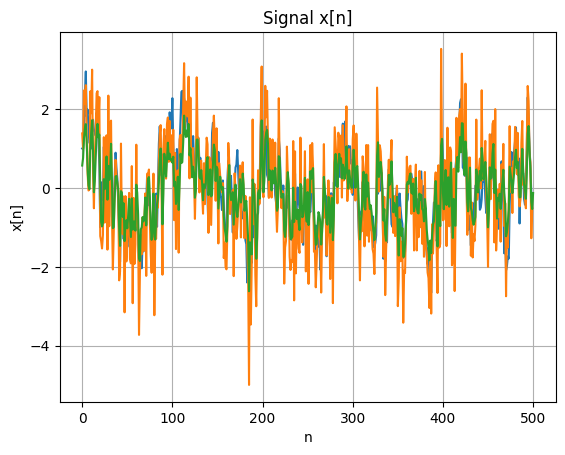

In [354]:
dhat = np.convolve(w_est, x)

plt.figure()
plt.plot(d)
plt.plot(x)
plt.plot(dhat)
plt.title('Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

##### Ex3.4 Multi P and error estimation
Let's observe the SNR if we increase the filter order (use the function *wienerFilterTheo()*).
Because of the non-linear phase of the Wiener FIR filter, the error signal can not be computed as **d-dhat**. There is a synchronisation problem. The SNR gain can not be computed as $10log_{10}\left(\frac{||d||}{||d-dhat||}\right)$. When p increases, the SNR gain increases but $10log_{10}\left(\frac{||d||}{||d-dhat||}\right)$ increases and then decreases ! Do not use it !

- Increase the filter order between 1 to 8 and compute for each order:
  - compute the filter coefficients by using *wienerFilterTheo()*
  - SNR with the formula $10\cdot log_{10} (Pd/Pv)$
  - filter the signal with the filter computed to obtain $dhat[n]$ 
  - SNR with the formula $10\cdot log_{10} (\frac{||d||}{||e||})$ where $e[n] = d[n]-dhat[n]$
- Display the filter coefficients and the SNR on a figure

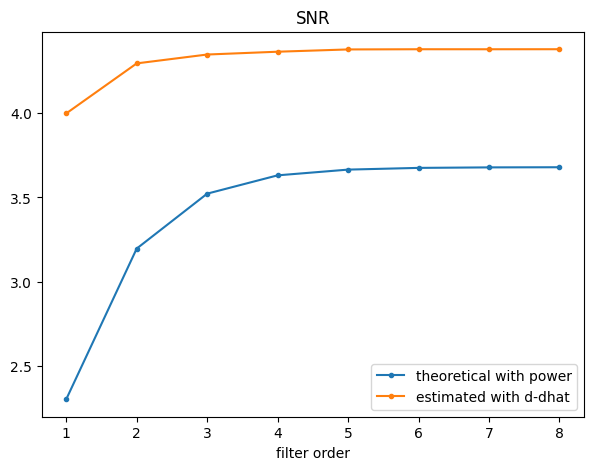

In [355]:
orders = np.arange(1, 9)
snr_theoretical = []
snr_practical = []

for p_order in orders:
    # 1. On récupère TOUT (w et les matrices Rd, Rv correspondantes à cet ordre)
    w_p, E_p, rd_p, Rd_p, Rv_p, Rx_p = wienerFilterTheo(SigmaV, a1, p_order)
    
    # 2. SNR théorique (via les puissances filtrées)
    Pd = w_p @ Rd_p @ w_p
    Pv = w_p @ Rv_p @ w_p
    snr_theoretical.append(10 * np.log10(Pd / Pv))
    
    # 3. Filtrage pratique
    dhat = signal.lfilter(w_p, 1, x)
    
    # 4. SNR pratique (via le signal d'erreur d - dhat)
    error_signal = d - dhat
    # On calcule la puissance de d et de l'erreur
    snr_p = 10 * np.log10(np.sum(d**2) / np.sum(error_signal**2))
    snr_practical.append(snr_p)

# --- Plot pour coller à ton image ---
plt.figure(figsize=(7, 5))
plt.plot(orders, snr_theoretical, '.-', label='theoretical with power')
plt.plot(orders, snr_practical, '.-', label='estimated with d-dhat')

plt.title('SNR')
plt.xlabel('filter order')
# Pas de ylabel sur ton image, mais on peut le mettre si besoin
plt.legend(loc='lower right') # La légende est en bas à droite sur ton image
plt.show()

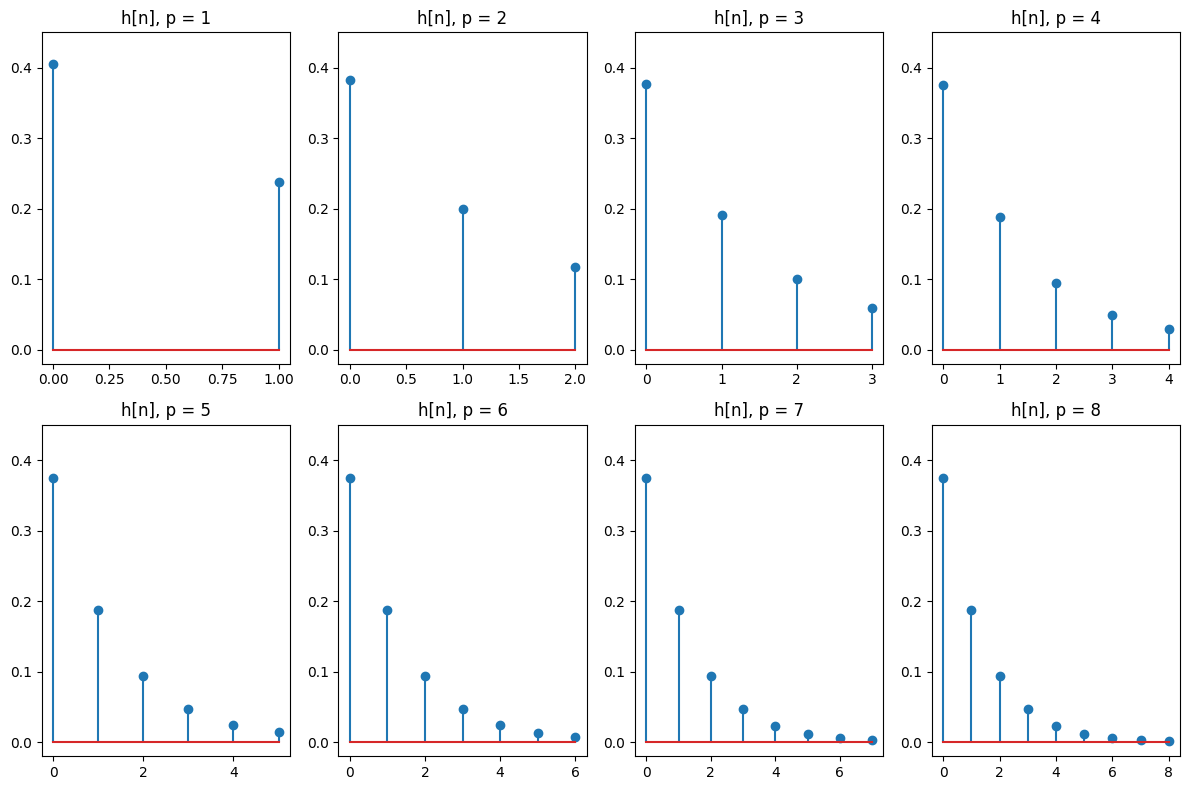

In [357]:
# --- Configuration de la grille 2x4 ---
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten() # Pour itérer facilement sur les 8 cases

orders = np.arange(1, 9)

for i, p_val in enumerate(orders):
    # 1. Calcul des poids pour l'ordre actuel
    # Rappel : l'ordre 'p_val' renvoie p_val + 1 coefficients
    w_p, _, _, _, _, _ = wienerFilterTheo(SigmaV, a1, p_val)
    
    # 2. Création du stem plot sur la case correspondante
    axes[i].stem(np.arange(len(w_p)), w_p)
    
    # 3. Cosmétique pour coller à ton image
    axes[i].set_title(f'h[n], p = {p_val}')
    axes[i].set_ylim([-0.02, 0.45]) # Pour que l'échelle soit la même partout
    axes[i].grid(False) # Pas de grille sur ton modèle

# Ajustement automatique de l'espacement
plt.tight_layout()
plt.show()